# Quantile regression: predicting a range, not a number

### An interval is only worth having if you check how often it is right

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com) ·
[all notebooks](../../CURRICULUM.md)

---

| | |
|---|---|
| **What you will learn** | What the pinball loss is and why minimising it returns a quantile, how to solve it exactly as a linear program, how to measure whether a predicted interval covers what it claims, and why two quantile models can cross each other |
| **You should already know** | [Linear regression](../01-linear-regression/) and [outlier-resistant regression](../07-outlier-resistant-regression/) |
| **Datasets** | A synthetic fan with spread that grows, then Bike Sharing |
| **Runtime** | Around three minutes on a laptop CPU |
| **Next** | [02-09 Generalised linear models](../09-generalised-linear-models/), which fixes the distribution rather than the question |

---

## 1. The question a point prediction cannot answer

Squared error trains a model to predict the conditional mean. That is a
perfectly good answer to "how many bicycles will be hired at 5pm", and a
useless answer to "how many racks do I need so that 5pm goes fine nine days out
of ten".

The second question is about a quantile, and quantiles are not something you
can read off a mean. Two hours can share a mean of two hundred hires and have
completely different spreads: a placid Tuesday afternoon and a Friday evening
that is either dead or overwhelmed depending on the weather. A model that
returns one number for both is discarding the difference on purpose.

Quantile regression keeps it. Instead of one model of the middle you fit one
model per quantile you care about, each with its own loss, and the gap between
two of them is a predicted interval.

The whole method is one asymmetric loss function, so section 3 builds it from
nothing. But the part that decides whether any of this is useful is section 6,
where the intervals get checked. **A 10 to 90 interval is a promise that eight
out of ten held-out points fall inside it.** That promise is testable, it is
almost never tested, and testing it is the reason this notebook exists.

In [1]:
import sys
import pathlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "toolkit").is_dir())
sys.path.insert(0, str(ROOT))

from toolkit import style, datasets

style.use()
FIG = pathlib.Path("figures")
FIG.mkdir(exist_ok=True)
SEED = 0

QUANTILES = [0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95]
PAIRS = [(0.05, 0.95), (0.10, 0.90), (0.25, 0.75)]

print(f"quantiles fitted   : {QUANTILES}")
print(f"intervals checked  : {[f'{lo:.0%}-{hi:.0%}' for lo, hi in PAIRS]}")
print(f"nominal coverage   : {[f'{hi - lo:.0%}' for lo, hi in PAIRS]}")

quantiles fitted   : [0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95]
intervals checked  : ['5%-95%', '10%-90%', '25%-75%']
nominal coverage   : ['90%', '80%', '50%']


## 2. The pinball loss

For a target $y$, a prediction $\hat y$ and a quantile level $q \in (0, 1)$:

$$L_q(y, \hat y) = \begin{cases}
q\,(y - \hat y) & y \ge \hat y \\
(1 - q)\,(\hat y - y) & y < \hat y
\end{cases}$$

Both branches are non-negative and the function is piecewise linear with a kink
at zero, which is where the name comes from: plotted against the residual it
looks like a pinball bouncing off a wedge.

The asymmetry is the mechanism. At $q = 0.9$, being too low costs nine times
what being too high costs, so the fit climbs until only a tenth of the points
are still above it. At $q = 0.5$ the two costs are equal, the loss is
proportional to absolute error, and the answer is the median.

### Why the minimiser is the quantile

Worth doing, because it is four lines and it explains the whole method.

Take the expected loss over $Y$ for a fixed prediction $t$, and split it at
$t$:

$$\mathbb{E}[L_q(Y, t)] = q\int_t^\infty (y - t)\,dF(y) + (1 - q)\int_{-\infty}^t (t - y)\,dF(y)$$

Differentiate with respect to $t$. The first term gives $-q\,(1 - F(t))$, the
second gives $(1 - q)F(t)$, and the boundary terms vanish because the
integrand is zero at $y = t$:

$$\frac{d}{dt}\mathbb{E}[L_q(Y, t)] = -q + F(t)$$

Set that to zero and $F(t) = q$, so $t$ is the $q$-th quantile of $Y$. The
derivative is increasing in $t$, so it is a minimum. Nothing here assumed a
distribution, which is the appeal: the quantile you get is whatever the data's
own quantile is, not the quantile of a normal curve fitted to it.

## 3. From scratch

### The loss, and the claim it makes about constants

In [2]:
def pinball(y_true, y_pred, q):
    """The pinball loss, averaged over rows. Three lines and no library."""
    error = np.asarray(y_true, dtype=float) - np.asarray(y_pred, dtype=float)
    return float(np.mean(np.maximum(q * error, (q - 1.0) * error)))


rng = np.random.default_rng(SEED)
sample = rng.gamma(shape=2.0, scale=30.0, size=4000)     # skewed on purpose
candidates = np.linspace(sample.min(), np.quantile(sample, 0.995), 900)

print(f"{'q':>6} {'argmin of the loss':>20} {'np.quantile':>14} {'gap':>10}")
for q in [0.10, 0.50, 0.90]:
    losses = np.array([pinball(sample, c, q) for c in candidates])
    best = candidates[int(np.argmin(losses))]
    truth = float(np.quantile(sample, q))
    print(f"{q:>6.2f} {best:>20.3f} {truth:>14.3f} {abs(best - truth):>10.4f}")

grid_res = candidates[1] - candidates[0]
print(f"\nthe grid step is {grid_res:.3f}, so a gap of that size is the search, not the method")

     q   argmin of the loss    np.quantile        gap
  0.10               16.079         15.991     0.0885
  0.50               50.024         50.110     0.0859
  0.90              118.897        118.807     0.0899

the grid step is 0.246, so a gap of that size is the search, not the method


my pinball at q=0.9 : 10.505835
sklearn's           : 10.505835


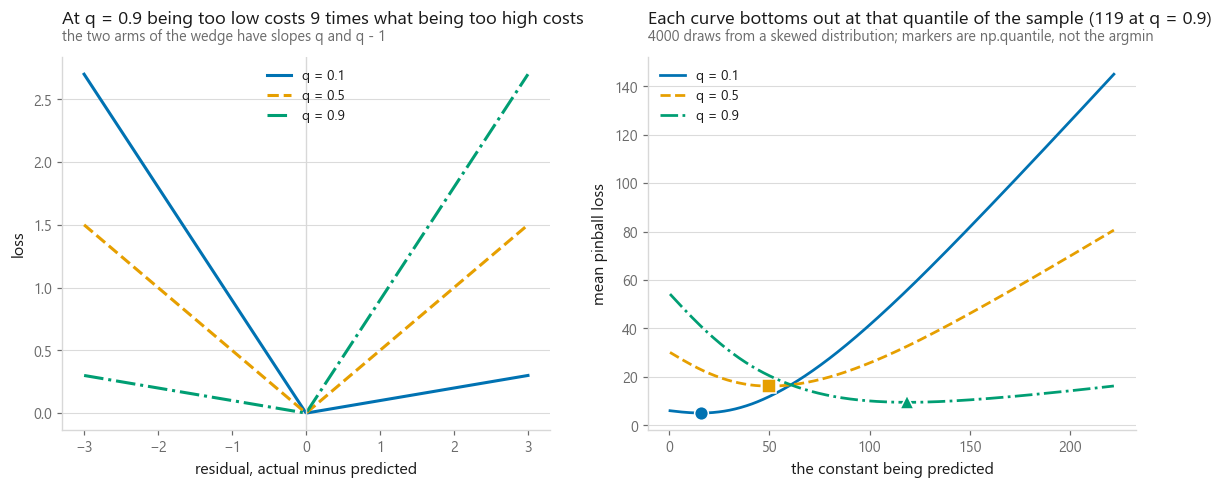

In [3]:
from sklearn.metrics import mean_pinball_loss

residual = np.linspace(-3, 3, 400)
fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.4))

ax = axes[0]
for i, q in enumerate([0.10, 0.50, 0.90]):
    ax.plot(residual, np.maximum(q * residual, (q - 1) * residual),
            color=style.PALETTE[i], ls=style.DASHES[i], lw=2.0, label=f"q = {q}")
ax.axvline(0, color=style.RULE, lw=0.9)
ax.set_xlabel("residual, actual minus predicted")
ax.set_ylabel("loss")
ax.legend(fontsize=9)
style.title(ax,
            f"At q = 0.9 being too low costs {0.9 / 0.1:.0f} times what being too high costs",
            "the two arms of the wedge have slopes q and q - 1")

ax = axes[1]
for i, q in enumerate([0.10, 0.50, 0.90]):
    losses = np.array([pinball(sample, c, q) for c in candidates])
    ax.plot(candidates, losses, color=style.PALETTE[i], ls=style.DASHES[i], lw=1.8,
            label=f"q = {q}")
    ax.plot(np.quantile(sample, q), losses.min(), marker=style.MARKERS[i],
            color=style.PALETTE[i], markersize=9, markeredgecolor="white")
ax.set_xlabel("the constant being predicted")
ax.set_ylabel("mean pinball loss")
ax.legend(fontsize=9)
style.title(ax,
            f"Each curve bottoms out at that quantile of the sample "
            f"({np.quantile(sample, 0.9):.0f} at q = 0.9)",
            f"{len(sample)} draws from a skewed distribution; markers are np.quantile, not the argmin")
style.save(fig, FIG / "fig-01-pinball-loss.png")

print(f"my pinball at q=0.9 : {pinball(sample, 150.0, 0.9):.6f}")
print(f"sklearn's           : {mean_pinball_loss(sample, np.full(len(sample), 150.0), alpha=0.9):.6f}")

### Fitting a line: the loss is a linear program

The pinball loss has no derivative at zero, so the normal equation is not
available. What is available is better. Split each residual into a positive
part $u_i$ and a negative part $v_i$, both non-negative, with
$y_i - x_i^\top w = u_i - v_i$. Then the objective is linear:

$$\min_{w, u, v}\ \sum_i q\,u_i + (1 - q)\,v_i
\quad\text{subject to}\quad Xw + u - v = y,\ u \ge 0,\ v \ge 0$$

That is a linear program, solvable exactly. The one wrinkle is that $w$ is free
in sign and linear program solvers want non-negative variables, so each weight
is written as a difference of two non-negative variables.

scikit-learn's `QuantileRegressor` does exactly this, which is why it is
noticeably slower than `LinearRegression` and why it gets the answer rather
than approaching it.

In [4]:
from scipy.optimize import linprog


def quantile_lp(X, y, q):
    """Exact quantile regression by linear programming.

    Variables are stacked as [w+, w-, u, v]. The objective ignores the weight
    variables entirely, which is what makes this a fit rather than a penalty.
    """
    n, p = X.shape
    cost = np.concatenate([np.zeros(2 * p), q * np.ones(n), (1 - q) * np.ones(n)])
    A_eq = np.hstack([X, -X, np.eye(n), -np.eye(n)])
    out = linprog(cost, A_eq=A_eq, b_eq=y, bounds=[(0, None)] * (2 * p + 2 * n),
                  method="highs")
    return out.x[:p] - out.x[p:2 * p]


def quantile_subgradient(X, y, q, iters=20_000, lr=2.0):
    """The same fit by subgradient descent, for comparison.

    The gradient of the pinball loss is q where the residual is positive and
    q - 1 where it is negative, with a kink in between. Subgradient methods do
    not converge to the optimum with a fixed step, so the step decays and the
    iterates are averaged, which is the standard repair.
    """
    w = np.zeros(X.shape[1])
    w[0] = np.quantile(y, q)
    averaged = w.copy()
    for t in range(1, iters + 1):
        error = y - X @ w
        grad = -X.T @ np.where(error > 0, q, q - 1.0) / len(y)
        w = w - lr / np.sqrt(t) * grad
        averaged += (w - averaged) / (t + 1)
    return averaged


# a fan: the spread grows with x, which is the situation quantile regression is for
n_fan = 300
x_fan = rng.uniform(0, 10, n_fan)
y_fan = 5 + 2 * x_fan + rng.normal(0, 0.5 + 0.6 * x_fan, n_fan)
x_std = (x_fan - x_fan.mean()) / x_fan.std()
design = np.column_stack([np.ones(n_fan), x_std])

from sklearn.linear_model import QuantileRegressor

print(f"{'q':>5} {'LP loss':>10} {'subgradient':>12} {'sklearn':>10} "
      f"{'below the LP line':>19}")
lp_fits = {}
for q in [0.10, 0.50, 0.90]:
    w_lp = quantile_lp(design, y_fan, q)
    w_sg = quantile_subgradient(design, y_fan, q)
    sk = QuantileRegressor(quantile=q, alpha=0.0, solver="highs").fit(x_std[:, None], y_fan)
    lp_fits[q] = w_lp
    print(f"{q:>5.2f} {pinball(y_fan, design @ w_lp, q):>10.5f} "
          f"{pinball(y_fan, design @ w_sg, q):>12.5f} "
          f"{pinball(y_fan, sk.predict(x_std[:, None]), q):>10.5f} "
          f"{(y_fan <= design @ w_lp).mean():>19.4f}")

    q    LP loss  subgradient    sklearn   below the LP line


 0.10    0.67087      0.67236    0.67087              0.1033


 0.50    1.40742      1.40745    1.40742              0.5033


 0.90    0.58846      0.58930    0.58846              0.9000


Three things in that table.

The linear program and scikit-learn agree, which is expected, because they are
the same linear program handed to the same solver.

The subgradient version does not quite agree, and it is the honest reason the
library does not use one. The full decaying schedule in the cell above, with
averaged iterates, still leaves a gap in the tails, where the loss is nearly
flat along one direction and gradient information is thin. On the median it is
fine. This is a case where the special structure of the problem beats a general
optimiser, and knowing that is worth more than a faster learning rate.

The last column is the in-sample guarantee. The fraction of training points at
or below the fitted line comes out at the quantile you asked for. That is not a
coincidence, it is a property of the optimum: at the solution the subgradient
must contain zero, which pins the fraction of positive residuals to $q$.

**That guarantee is in sample.** It says nothing about held-out data, which is
the entire subject of section 6.

band width at the low end  : 2.63


band width at the high end : 13.33
in-sample coverage of the 10-90 band: 0.8033


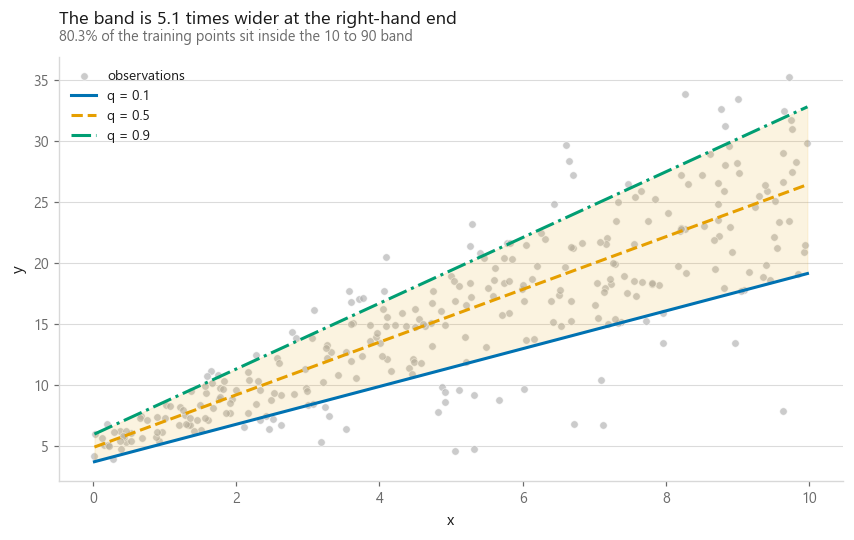

In [5]:
fig, ax = plt.subplots(figsize=(9.2, 5.0))

order = np.argsort(x_fan)
ax.scatter(x_fan, y_fan, s=24, color=style.NEUTRAL, alpha=0.65, edgecolor="white",
           linewidth=0.5, label="observations")

for i, q in enumerate([0.10, 0.50, 0.90]):
    fitted = (design @ lp_fits[q])[order]
    ax.plot(x_fan[order], fitted, color=style.PALETTE[i], ls=style.DASHES[i], lw=2.0,
            label=f"q = {q}")

band_lo = (design @ lp_fits[0.10])[order]
band_hi = (design @ lp_fits[0.90])[order]
ax.fill_between(x_fan[order], band_lo, band_hi, color=style.PALETTE[1], alpha=0.12)

inside = ((y_fan >= design @ lp_fits[0.10]) & (y_fan <= design @ lp_fits[0.90])).mean()
lo_width = float(band_hi[:20].mean() - band_lo[:20].mean())
hi_width = float(band_hi[-20:].mean() - band_lo[-20:].mean())

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend(fontsize=9, loc="upper left")
style.title(ax,
            f"The band is {hi_width / lo_width:.1f} times wider at the right-hand end",
            f"{inside:.1%} of the training points sit inside the 10 to 90 band")
style.save(fig, FIG / "fig-02-fan.png")

print(f"band width at the low end  : {lo_width:.2f}")
print(f"band width at the high end : {hi_width:.2f}")
print(f"in-sample coverage of the 10-90 band: {inside:.4f}")

A single least squares line cannot produce that picture. It would give one
slope and one residual spread, and any interval built from it would be the same
width everywhere. The three lines above have three different slopes, which is
quantile regression saying that the top of the distribution grows faster with x
than the bottom does.

## 4. In practice, on Bike Sharing

Hourly bicycle hires in Washington DC, which are heteroskedastic for an obvious
reason: a quiet hour cannot vary much because it is near zero, and a rush hour
can vary enormously. If the interval width does not change across the day, the
model is not describing this dataset.

Two models, deliberately different in kind.

`QuantileRegressor` is the linear program above with an L1 penalty available.
`GradientBoostingRegressor(loss="quantile")` is a forest of trees grown against
the same pinball loss, so it can bend where the linear model cannot.

In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

X_bike, y_bike = datasets.bike_sharing()

CATEGORICAL = ["season", "mnth", "hr", "weekday", "weathersit"]
NUMERIC = ["yr", "holiday", "workingday", "temp", "atemp", "hum", "windspeed"]

# Hour is a label, not a quantity: hour 23 sits next to hour 0, and no linear
# term in hr can express that. One-hot lets each hour have its own level.
prep = ColumnTransformer([
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False),
     CATEGORICAL),
    ("num", "passthrough", NUMERIC),
])

X_tr, X_te, y_tr, y_te = train_test_split(X_bike, y_bike, test_size=0.25,
                                          random_state=SEED)
A = prep.fit_transform(X_tr).astype(float)
B = prep.transform(X_te).astype(float)
y_tr = y_tr.to_numpy(dtype=float)
y_te = y_te.to_numpy(dtype=float)
hour_te = X_te["hr"].to_numpy()

print(f"train {A.shape[0]} rows x {A.shape[1]} columns, test {B.shape[0]} rows")
print(f"hires per hour: min {y_bike.min()}, median {np.median(y_bike):.0f}, "
      f"max {y_bike.max()}")

train 13034 rows x 53 columns, test 4345 rows
hires per hour: min 1, median 142, max 977


In [7]:
import time

t0 = time.time()
linear_q = {q: QuantileRegressor(quantile=q, alpha=0.0, solver="highs").fit(A, y_tr)
            for q in QUANTILES}
t_linear = time.time() - t0

t0 = time.time()
tree_q = {q: GradientBoostingRegressor(loss="quantile", alpha=q, n_estimators=200,
                                       max_depth=4, learning_rate=0.1,
                                       random_state=SEED).fit(A, y_tr)
          for q in QUANTILES}
t_tree = time.time() - t0

P_linear = {q: m.predict(B) for q, m in linear_q.items()}
P_tree = {q: m.predict(B) for q, m in tree_q.items()}

print(f"{len(QUANTILES)} linear programs   : {t_linear:.1f}s")
print(f"{len(QUANTILES)} gradient boosters : {t_tree:.1f}s")

losses = pd.DataFrame([{"q": q,
                        "linear": mean_pinball_loss(y_te, P_linear[q], alpha=q),
                        "boosted trees": mean_pinball_loss(y_te, P_tree[q], alpha=q)}
                       for q in QUANTILES])
losses["trees better by"] = losses["linear"] - losses["boosted trees"]
print()
print(losses.to_string(index=False, float_format="{:.3f}".format))

7 linear programs   : 77.0s
7 gradient boosters : 54.5s

    q  linear  boosted trees  trees better by
0.050   6.837          7.148           -0.311
0.100  12.569         11.290            1.278
0.250  26.029         18.786            7.243
0.500  36.453         22.585           13.868
0.750  30.604         18.121           12.483
0.900  16.977         10.849            6.128
0.950   9.703          7.077            2.627


## 5. The measurement that decides whether any of this worked

The pinball loss above is the training objective, so of course each model looks
reasonable on it. It does not tell you whether the intervals are honest.

**Coverage does.** For each quantile level, the fraction of held-out points
that fall at or below the prediction should be that level. For each pair, the
fraction inside the band should be the difference between the two levels. Both
are one line of NumPy and neither is standard practice, which is strange for a
method whose entire output is an interval.

In [8]:
coverage = pd.DataFrame([{"q": q,
                          "linear": float((y_te <= P_linear[q]).mean()),
                          "boosted trees": float((y_te <= P_tree[q]).mean())}
                         for q in QUANTILES])
coverage["linear error"] = coverage["linear"] - coverage["q"]
coverage["trees error"] = coverage["boosted trees"] - coverage["q"]
print("fraction of held-out hours at or below each predicted quantile")
print(coverage.to_string(index=False, float_format="{:.4f}".format))

intervals = []
for lo, hi in PAIRS:
    for name, P in [("linear", P_linear), ("boosted trees", P_tree)]:
        band = (y_te >= P[lo]) & (y_te <= P[hi])
        intervals.append({"model": name, "interval": f"{lo:.0%}-{hi:.0%}",
                          "nominal": hi - lo, "empirical": float(band.mean()),
                          "mean width": float((P[hi] - P[lo]).mean())})
intervals = pd.DataFrame(intervals)
intervals["miss"] = intervals["empirical"] - intervals["nominal"]
print()
print(intervals.to_string(index=False, float_format="{:.4f}".format))

fraction of held-out hours at or below each predicted quantile
     q  linear  boosted trees  linear error  trees error
0.0500  0.0518         0.0513        0.0018       0.0013
0.1000  0.1036         0.1029        0.0036       0.0029
0.2500  0.2555         0.2479        0.0055      -0.0021
0.5000  0.5013         0.4863        0.0013      -0.0137
0.7500  0.7418         0.7432       -0.0082      -0.0068
0.9000  0.8969         0.8868       -0.0031      -0.0132
0.9500  0.9482         0.9386       -0.0018      -0.0114

        model interval  nominal  empirical  mean width    miss
       linear   5%-95%   0.9000     0.8964    285.7758 -0.0036
boosted trees   5%-95%   0.9000     0.8872    244.0196 -0.0128
       linear  10%-90%   0.8000     0.7933    233.7605 -0.0067
boosted trees  10%-90%   0.8000     0.7839    175.7440 -0.0161
       linear  25%-75%   0.5000     0.4863    131.1037 -0.0137
boosted trees  25%-75%   0.5000     0.4967     83.6190 -0.0033


        linear    5%-95%: promised 90%, delivered 89.6%, mean width 285.8 hires
 boosted trees    5%-95%: promised 90%, delivered 88.7%, mean width 244.0 hires
        linear   10%-90%: promised 80%, delivered 79.3%, mean width 233.8 hires
 boosted trees   10%-90%: promised 80%, delivered 78.4%, mean width 175.7 hires
        linear   25%-75%: promised 50%, delivered 48.6%, mean width 131.1 hires
 boosted trees   25%-75%: promised 50%, delivered 49.7%, mean width 83.6 hires


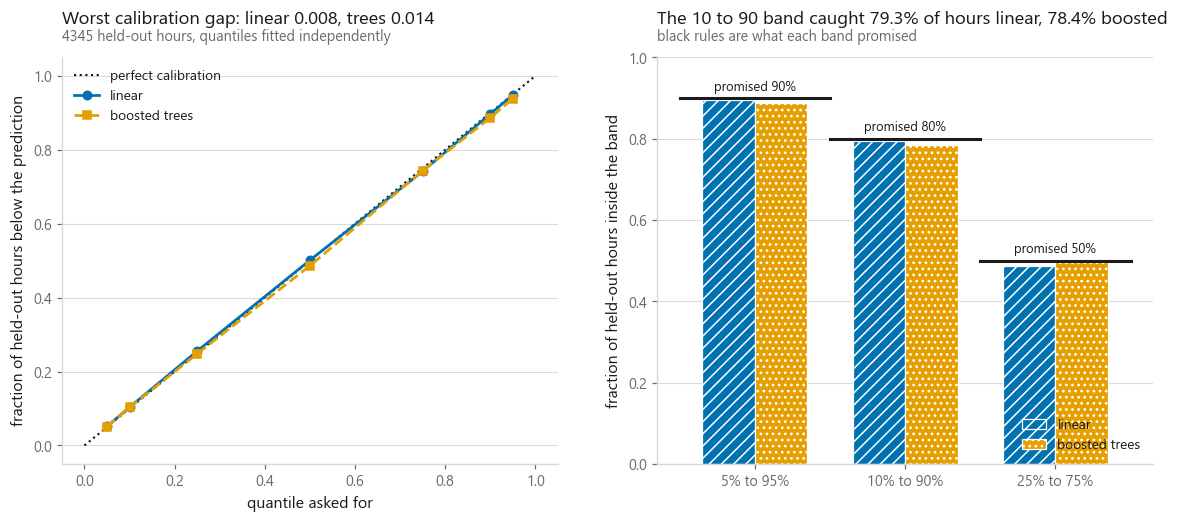

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.8))

ax = axes[0]
ax.plot([0, 1], [0, 1], color=style.INK, ls=":", lw=1.4, label="perfect calibration")
for i, name in enumerate(["linear", "boosted trees"]):
    ax.plot(coverage["q"], coverage[name], color=style.PALETTE[i], ls=style.DASHES[i],
            marker=style.MARKERS[i], lw=1.8, label=name)
ax.set_xlabel("quantile asked for")
ax.set_ylabel("fraction of held-out hours below the prediction")
ax.legend(fontsize=9)
worst_lin = coverage["linear error"].abs().max()
worst_tree = coverage["trees error"].abs().max()
style.title(ax,
            f"Worst calibration gap: linear {worst_lin:.3f}, trees {worst_tree:.3f}",
            f"{len(y_te)} held-out hours, quantiles fitted independently")

ax = axes[1]
band_w = 0.35
x = np.arange(len(PAIRS))
lin_rows = intervals[intervals["model"] == "linear"].reset_index(drop=True)
tree_rows = intervals[intervals["model"] == "boosted trees"].reset_index(drop=True)
ax.bar(x - band_w / 2, lin_rows["empirical"], band_w, color=style.PALETTE[0],
       hatch="///", edgecolor="white", linewidth=0.8, label="linear")
ax.bar(x + band_w / 2, tree_rows["empirical"], band_w, color=style.PALETTE[1],
       hatch="...", edgecolor="white", linewidth=0.8, label="boosted trees")
for i, (lo, hi) in enumerate(PAIRS):
    ax.plot([i - 0.5, i + 0.5], [hi - lo, hi - lo], color=style.INK, lw=2.0)
    ax.annotate(f"promised {hi - lo:.0%}", xy=(i, hi - lo), xytext=(0, 5),
                textcoords="offset points", ha="center", fontsize=8.5, color=style.INK)
ax.set_xticks(x, [f"{lo:.0%} to {hi:.0%}" for lo, hi in PAIRS])
ax.set_ylim(0, 1.0)
ax.set_ylabel("fraction of held-out hours inside the band")
ax.legend(fontsize=9, loc="lower right")
mid = intervals[intervals["interval"] == "10%-90%"].set_index("model")
style.title(ax,
            f"The 10 to 90 band caught {mid.loc['linear', 'empirical']:.1%} of hours "
            f"linear, {mid.loc['boosted trees', 'empirical']:.1%} boosted",
            "black rules are what each band promised")
style.save(fig, FIG / "fig-03-coverage.png")

for _, row in intervals.iterrows():
    print(f"{row['model']:>14} {row['interval']:>9}: promised {row['nominal']:.0%}, "
          f"delivered {row['empirical']:.1%}, mean width {row['mean width']:.1f} hires")

### Sharpness and calibration pull in opposite directions

Read the width column next to the coverage column and the tradeoff is visible.
The boosted model produces narrower bands, and it also catches fewer points
than it promised. The linear model produces wider bands and lands closer to its
promise.

Neither is automatically the better model, because an interval has two virtues
that fight. **Calibration** is keeping the promise. **Sharpness** is the
promise being worth something: an interval from zero to a thousand hires
catches everything and helps nobody. Any model can buy coverage by widening,
so a coverage number without a width number next to it is not a result.

The pinball loss is the referee for that fight, which is why the loss table in
section 4 and the coverage table here are both needed. One is the score, the
other is the audit.

## 6. Average coverage hides where the coverage went

The numbers above are marginal: they average over every hour of every day. A
model can hit its target on average by over-covering the quiet hours and
under-covering the busy ones, and for a planning problem that is the worst
possible way to be right.

So condition on something. Hour of day is the natural choice here.

In [10]:
inside_lin = (y_te >= P_linear[0.10]) & (y_te <= P_linear[0.90])
inside_tree = (y_te >= P_tree[0.10]) & (y_te <= P_tree[0.90])

by_hour = pd.DataFrame({"hour": hour_te, "linear": inside_lin,
                        "boosted trees": inside_tree}).groupby("hour").mean()
by_hour["rows"] = pd.Series(hour_te).value_counts().sort_index().to_numpy()

print("coverage of the 10 to 90 band, by hour of day")
print(by_hour.to_string(float_format="{:.3f}".format))
print(f"\nlinear: marginal {inside_lin.mean():.3f}, "
      f"worst hour {by_hour['linear'].min():.3f} at {int(by_hour['linear'].idxmin())}:00, "
      f"best hour {by_hour['linear'].max():.3f} at {int(by_hour['linear'].idxmax())}:00")
print(f"trees : marginal {inside_tree.mean():.3f}, "
      f"worst hour {by_hour['boosted trees'].min():.3f} at "
      f"{int(by_hour['boosted trees'].idxmin())}:00, "
      f"best hour {by_hour['boosted trees'].max():.3f} at "
      f"{int(by_hour['boosted trees'].idxmax())}:00")

coverage of the 10 to 90 band, by hour of day
      linear  boosted trees  rows
hour                             
0      0.829          0.406   170
1      0.798          0.852   183
2      0.819          0.766   188
3      0.817          0.772   180
4      0.792          0.820   183
5      0.795          0.759   166
6      0.840          0.858   169
7      0.712          0.739   184
8      0.770          0.776   174
9      0.824          0.798   193
10     0.777          0.872   179
11     0.801          0.828   186
12     0.789          0.795   190
13     0.797          0.785   172
14     0.736          0.753   178
15     0.788          0.821   184
16     0.840          0.807   187
17     0.818          0.812   176
18     0.751          0.762   181
19     0.793          0.798   188
20     0.712          0.712   170
21     0.781          0.796   201
22     0.840          0.872   187
23     0.818          0.824   176

linear: marginal 0.793, worst hour 0.712 at 20:00, best hour 0.840 at

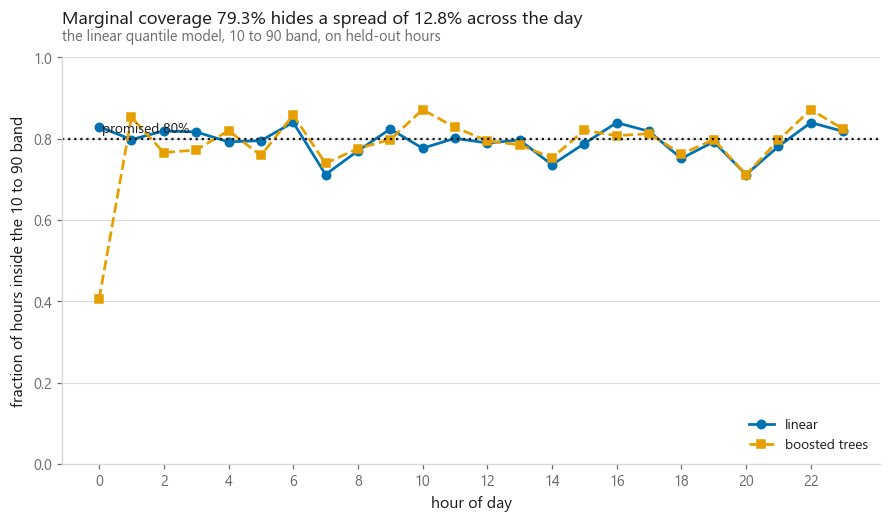

In [11]:
fig, ax = plt.subplots(figsize=(9.6, 4.8))

for i, name in enumerate(["linear", "boosted trees"]):
    ax.plot(by_hour.index, by_hour[name], color=style.PALETTE[i], ls=style.DASHES[i],
            marker=style.MARKERS[i], lw=1.8, label=name)
ax.axhline(0.80, color=style.INK, ls=":", lw=1.5)
ax.annotate("promised 80%", xy=(0, 0.80), xytext=(2, 4), textcoords="offset points",
            fontsize=9, color=style.INK)
ax.set_xticks(range(0, 24, 2))
ax.set_xlabel("hour of day")
ax.set_ylabel("fraction of hours inside the 10 to 90 band")
ax.set_ylim(0, 1.0)
ax.legend(fontsize=9, loc="lower right")
spread = by_hour["linear"].max() - by_hour["linear"].min()
style.title(ax,
            f"Marginal coverage {inside_lin.mean():.1%} hides a spread of "
            f"{spread:.1%} across the day",
            "the linear quantile model, 10 to 90 band, on held-out hours")
style.save(fig, FIG / "fig-04-coverage-by-hour.png")

## 7. Quantile crossing, which is a real failure and not a footnote

Each quantile here was fitted separately. Nothing in any of those fits knows
the others exist, and nothing enforces the one property a set of quantiles must
have: they have to be in order. The 90th percentile of anything is at least its
75th.

When two fitted quantiles swap places for some row, that is **quantile
crossing**, and it means the model has predicted a distribution that does not
exist. Most write-ups mention it in a sentence. It is countable, so count it.

In [12]:
adjacent = list(zip(QUANTILES[:-1], QUANTILES[1:]))
cross_rows = []
for name, P in [("linear", P_linear), ("boosted trees", P_tree)]:
    for lo, hi in adjacent:
        bad = int((P[hi] < P[lo]).sum())
        cross_rows.append({"model": name, "pair": f"{lo:.2f} vs {hi:.2f}",
                           "crossings": bad, "rate": bad / len(y_te)})
crossings = pd.DataFrame(cross_rows)
print(crossings.to_string(index=False, float_format="{:.4f}".format))

totals = crossings.groupby("model").agg(crossings=("crossings", "sum"))
totals["checks"] = len(adjacent) * len(y_te)
totals["rate"] = totals["crossings"] / totals["checks"]
print()
print(totals.to_string(float_format="{:.4f}".format))

# an example, if there is one
example = None
for lo, hi in adjacent:
    bad = np.flatnonzero(P_tree[hi] < P_tree[lo])
    if len(bad):
        example = (lo, hi, int(bad[0]))
        break
if example is not None:
    lo, hi, row = example
    print(f"\nheld-out row {row}, boosted trees, all seven predicted quantiles:")
    print("   " + "  ".join(f"q{q:.2f}={P_tree[q][row]:7.1f}" for q in QUANTILES))
    print(f"   q{hi:.2f} sits below q{lo:.2f} by {P_tree[lo][row] - P_tree[hi][row]:.1f} hires")

        model         pair  crossings   rate
       linear 0.05 vs 0.10        402 0.0925
       linear 0.10 vs 0.25        137 0.0315
       linear 0.25 vs 0.50          2 0.0005
       linear 0.50 vs 0.75          9 0.0021
       linear 0.75 vs 0.90         20 0.0046
       linear 0.90 vs 0.95        231 0.0532
boosted trees 0.05 vs 0.10        558 0.1284
boosted trees 0.10 vs 0.25        456 0.1049
boosted trees 0.25 vs 0.50        332 0.0764
boosted trees 0.50 vs 0.75        400 0.0921
boosted trees 0.75 vs 0.90        452 0.1040
boosted trees 0.90 vs 0.95        608 0.1399

               crossings  checks   rate
model                                  
boosted trees       2806   26070 0.1076
linear               801   26070 0.0307

held-out row 1, boosted trees, all seven predicted quantiles:
   q0.05=    3.1  q0.10=    2.0  q0.25=    4.2  q0.50=    4.0  q0.75=    0.5  q0.90=   22.0  q0.95=   17.1
   q0.10 sits below q0.05 by 1.1 hires


overall crossing rate: linear 3.07%, boosted trees 10.76%


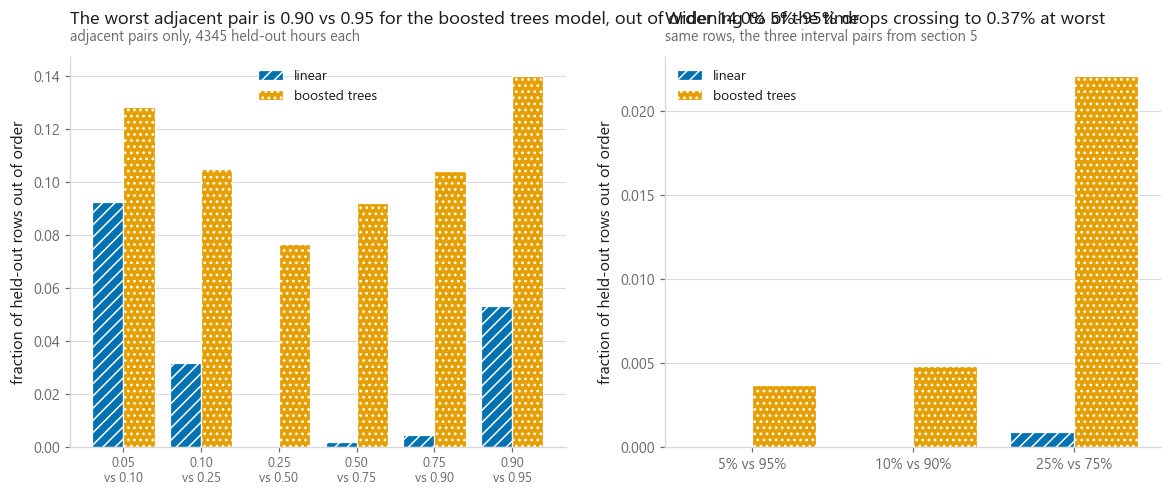

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.6))

ax = axes[0]
x = np.arange(len(adjacent))
lin_c = crossings[crossings["model"] == "linear"]["rate"].to_numpy()
tree_c = crossings[crossings["model"] == "boosted trees"]["rate"].to_numpy()
ax.bar(x - 0.2, lin_c, 0.4, color=style.PALETTE[0], hatch="///", edgecolor="white",
       linewidth=0.8, label="linear")
ax.bar(x + 0.2, tree_c, 0.4, color=style.PALETTE[1], hatch="...", edgecolor="white",
       linewidth=0.8, label="boosted trees")
ax.set_xticks(x, [f"{lo:.2f}\nvs {hi:.2f}" for lo, hi in adjacent], fontsize=8.5)
ax.set_ylabel("fraction of held-out rows out of order")
ax.legend(fontsize=9)
worst_pair = crossings.loc[crossings["rate"].idxmax()]
style.title(ax,
            f"The worst adjacent pair is {worst_pair['pair']} for the "
            f"{worst_pair['model']} model, out of order {worst_pair['rate']:.1%} of the time",
            f"adjacent pairs only, {len(y_te)} held-out hours each")

ax = axes[1]
far_rows = []
for name, P in [("linear", P_linear), ("boosted trees", P_tree)]:
    for lo, hi in PAIRS:
        far_rows.append({"model": name, "pair": f"{lo:.0%}-{hi:.0%}",
                         "rate": float((P[hi] < P[lo]).mean())})
far = pd.DataFrame(far_rows)
x = np.arange(len(PAIRS))
ax.bar(x - 0.2, far[far["model"] == "linear"]["rate"], 0.4, color=style.PALETTE[0],
       hatch="///", edgecolor="white", linewidth=0.8, label="linear")
ax.bar(x + 0.2, far[far["model"] == "boosted trees"]["rate"], 0.4, color=style.PALETTE[1],
       hatch="...", edgecolor="white", linewidth=0.8, label="boosted trees")
ax.set_xticks(x, [f"{lo:.0%} vs {hi:.0%}" for lo, hi in PAIRS])
ax.set_ylabel("fraction of held-out rows out of order")
ax.legend(fontsize=9)
style.title(ax,
            f"Widening to {PAIRS[0][0]:.0%}-{PAIRS[0][1]:.0%} drops crossing to "
            f"{far[far['pair'] == f'{PAIRS[0][0]:.0%}-{PAIRS[0][1]:.0%}']['rate'].max():.2%} "
            f"at worst",
            "same rows, the three interval pairs from section 5")
style.save(fig, FIG / "fig-05-crossing.png")

lin_total = float(totals.loc["linear", "rate"])
tree_total = float(totals.loc["boosted trees", "rate"])
print(f"overall crossing rate: linear {lin_total:.2%}, boosted trees {tree_total:.2%}")

### What to do about crossing

The cheapest fix costs one line and is what I would ship: sort the predicted
quantiles for each row. Sorting is a valid operation on a set of quantile
estimates, it cannot increase the total pinball loss by much, and it produces a
monotone answer. It is a patch over a symptom, and the symptom is that seven
independent fits were never constrained to agree.

The structural fixes are to fit one model that outputs all quantiles at once,
or to fit the conditional distribution and read quantiles off it, which is
where [generalised linear models](../09-generalised-linear-models/) and later
the distributional gradient boosters come in.

One more thing that the tables above turn up, and it is not a quantile problem
at all.

In [14]:
below_zero = {name: int((P[QUANTILES[0]] < 0).sum())
              for name, P in [("linear", P_linear), ("boosted trees", P_tree)]}
print(f"lowest quantile fitted: {QUANTILES[0]}")
for name, count in below_zero.items():
    print(f"  {name:>14}: predicted a negative number of bicycles for "
          f"{count} of {len(y_te)} held-out hours")
print(f"the actual minimum in the whole dataset is {y_bike.min()} hires")

lowest quantile fitted: 0.05
          linear: predicted a negative number of bicycles for 1011 of 4345 held-out hours
   boosted trees: predicted a negative number of bicycles for 212 of 4345 held-out hours
the actual minimum in the whole dataset is 1 hires


A negative count is not a calibration problem, a crossing problem, or an
outlier problem. It is a model that has never been told its target cannot go
below zero, and no choice of loss function fixes it, because the loss is not
where the assumption lives. The link function is.
[The next notebook](../09-generalised-linear-models/) changes that.

## Cheat sheet

| | |
|---|---|
| **Use it when** | The spread of the target changes across the input space, or the decision needs a range rather than a point |
| **The loss** | Pinball, asymmetric with slopes q and q - 1. Minimising it returns the q-th conditional quantile with no distributional assumption |
| **Linear version** | `QuantileRegressor`. Exact, solved as a linear program, slower than least squares. `alpha` adds an L1 penalty |
| **Non-linear version** | `GradientBoostingRegressor(loss="quantile", alpha=q)`. One model per quantile, so n quantiles cost n fits |
| **Always measure** | Held-out coverage against nominal, and interval width alongside it. Coverage without width can be bought by widening |
| **Watch out** | Independent fits can cross. Count how often before you decide whether to sort, and check coverage conditionally as well as marginally |
| **Does not fix** | A target with a hard bound. That needs a link function, not a loss |
| **Next** | [Generalised linear models](../09-generalised-linear-models/) |

## What to remember

1. The pinball loss is one asymmetric wedge, and minimising it returns a
   quantile. The four-line derivative argument is the whole justification.
2. Fitting it is a linear program, which is why `QuantileRegressor` is exact and
   slow. Subgradient descent on the same objective did not match it in the
   tails, and that gap is a fact about the method rather than about the tuning.
3. The fraction of training points below a fitted quantile line comes out at the
   level you asked for. That guarantee is in sample and says nothing about new
   data.
4. Held-out coverage is the measurement that matters, and it has to be read next
   to interval width. Coverage alone can always be bought by predicting a wider
   band.
5. The boosted model produced narrower intervals and caught fewer points than it
   promised. The linear model was closer to its promise and less useful per unit
   of width. That is calibration against sharpness, measured.
6. Marginal coverage hides conditional coverage. The by-hour chart spreads over
   a range that the single marginal number gives no hint of.
7. Independently fitted quantiles cross, most often between neighbouring levels.
   Count the crossings; do not assume they are rare because the write-up said so.
8. Quantile regression will happily predict a negative count. That is a link
   function problem and belongs to the next chapter.

---

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com)

Next: [02-09 Generalised linear models](../09-generalised-linear-models/) ·
Back to [the curriculum](../../CURRICULUM.md)

`#MachineLearning` `#QuantileRegression` `#PinballLoss` `#PredictionIntervals`
`#Calibration` `#ScikitLearn` `#Python` `#DataScience` `#MLTutorial`